# 04 - Feature Distributions

Explores the 15 ML features built in the gold layer: 
- covers null fractions (protohalo-derived features are partially missing)
- per-feature distributions split by the primary spurious label
- faceted distributions across simulation parameters (cosmology, softening, $z_{\rm ini}$),
- and spatial environment features.

All data in `gold.*` tables built by `make gold`:
- gold.labels
- gold.features
- gold.train_test_splits

## Setup

In [1]:
import warnings
import os
from pathlib import Path

project_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(project_root)

_latex = os.environ.get("LATEX_BIN_DIR")
if _latex:
    os.environ["PATH"] = _latex + ":" + os.environ["PATH"]

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import polars as pl

from src.config import load_config
from src.db import get_connection
from src.utils.plotting import apply_style

apply_style()

cfg = load_config()

FIGURES_DIR = Path("reports/figures")
from src.gold.features import FEATURE_COLS

## 1. Feature completeness

Three of the 15 features, i.e. `sphericity_s`, `log10_m_hmm`, and `a_hmm`, are derived from protohalo shape files and are null where `has_protohalo_data = False`.

In [10]:
conn = get_connection(cfg.database_path, read_only=True)
null_fracs_rows = []
for col in FEATURE_COLS:
    row = conn.execute(f"""
        SELECT
            '{col}' AS feature,
            COUNT(*)                                      AS n_total,
            SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) AS n_null
        FROM gold.features
    """).fetchone()
    null_fracs_rows.append(row)
conn.close()

null_df = pl.DataFrame(
    {"feature": [row[0] for row in null_fracs_rows],
     "n_total": [row[1] for row in null_fracs_rows],
     "n_null":  [row[2] for row in null_fracs_rows]},
)
null_df = null_df.with_columns(
    (pl.col("n_null") / pl.col("n_total")).alias("null_frac")
).sort("null_frac", descending=True)
print(null_df)

shape: (15, 4)
┌─────────────────────────────────┬─────────┬────────┬───────────┐
│ feature                         ┆ n_total ┆ n_null ┆ null_frac │
│ ---                             ┆ ---     ┆ ---    ┆ ---       │
│ str                             ┆ i64     ┆ i64    ┆ f64       │
╞═════════════════════════════════╪═════════╪════════╪═══════════╡
│ sphericity_s                    ┆ 613906  ┆ 156409 ┆ 0.254777  │
│ log10_m_hmm                     ┆ 613906  ┆ 156409 ┆ 0.254777  │
│ a_hmm                           ┆ 613906  ┆ 156409 ┆ 0.254777  │
│ log10_m200                      ┆ 613906  ┆ 0      ┆ 0.0       │
│ log10_npart                     ┆ 613906  ┆ 0      ┆ 0.0       │
│ …                               ┆ …       ┆ …      ┆ …         │
│ spin_bullock                    ┆ 613906  ┆ 0      ┆ 0.0       │
│ axis_ratio_b_over_a             ┆ 613906  ┆ 0      ┆ 0.0       │
│ axis_ratio_c_over_a             ┆ 613906  ┆ 0      ┆ 0.0       │
│ dist_nearest_neighbour_mpc_h    ┆ 613906  ┆ 0

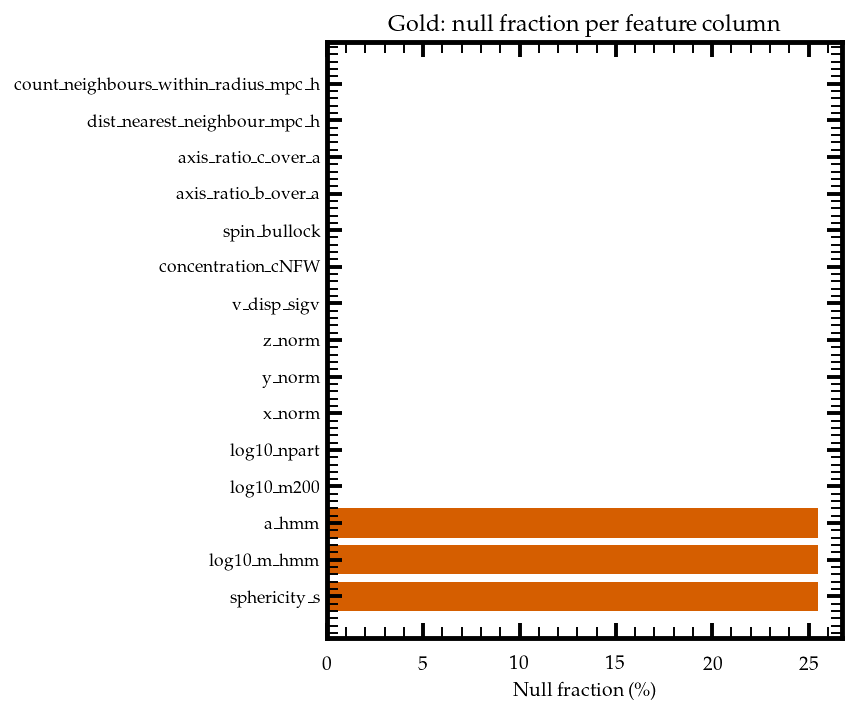

In [3]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
features  = null_df["feature"].to_list()
null_pcts = (null_df["null_frac"] * 100).to_list()
colors_bar = ["#D55E00" if p > 0 else "#0C5DA5" for p in null_pcts]

_ = ax.barh(range(len(features)), null_pcts, color=colors_bar)
_ = ax.set_yticks(range(len(features)))
_ = ax.set_yticklabels(features, fontsize=9)
_ = ax.set_xlabel(r"Null fraction (\%)")
_ = ax.set_title("Gold: null fraction per feature column")
fig.savefig(FIGURES_DIR / "04_feature_null_fractions.png", dpi=200, bbox_inches="tight")

## 2. Distributions by spurious label

We show box plots for each feature, split by `is_spurious_cdm_match`. Only WDM haloes with non-null labels are included. 

Spurious: orange (`#D55E00`), genuine: blue (`#0C5DA5`).

In [4]:
def load_wdm_features() -> pl.DataFrame:
    """Load gold.features joined with is_spurious_cdm_match for WDM haloes."""
    conn = get_connection(cfg.database_path, read_only=True)
    df = conn.execute("""
        SELECT f.*, l.is_spurious_cdm_match
        FROM gold.features f
        JOIN gold.labels l
            ON f.halo_id = l.halo_id AND f.simulation_id = l.simulation_id
        WHERE f.cosmology = 'WDM'
          AND l.is_spurious_cdm_match IS NOT NULL
    """).pl()
    conn.close()
    return df

wdm = load_wdm_features()

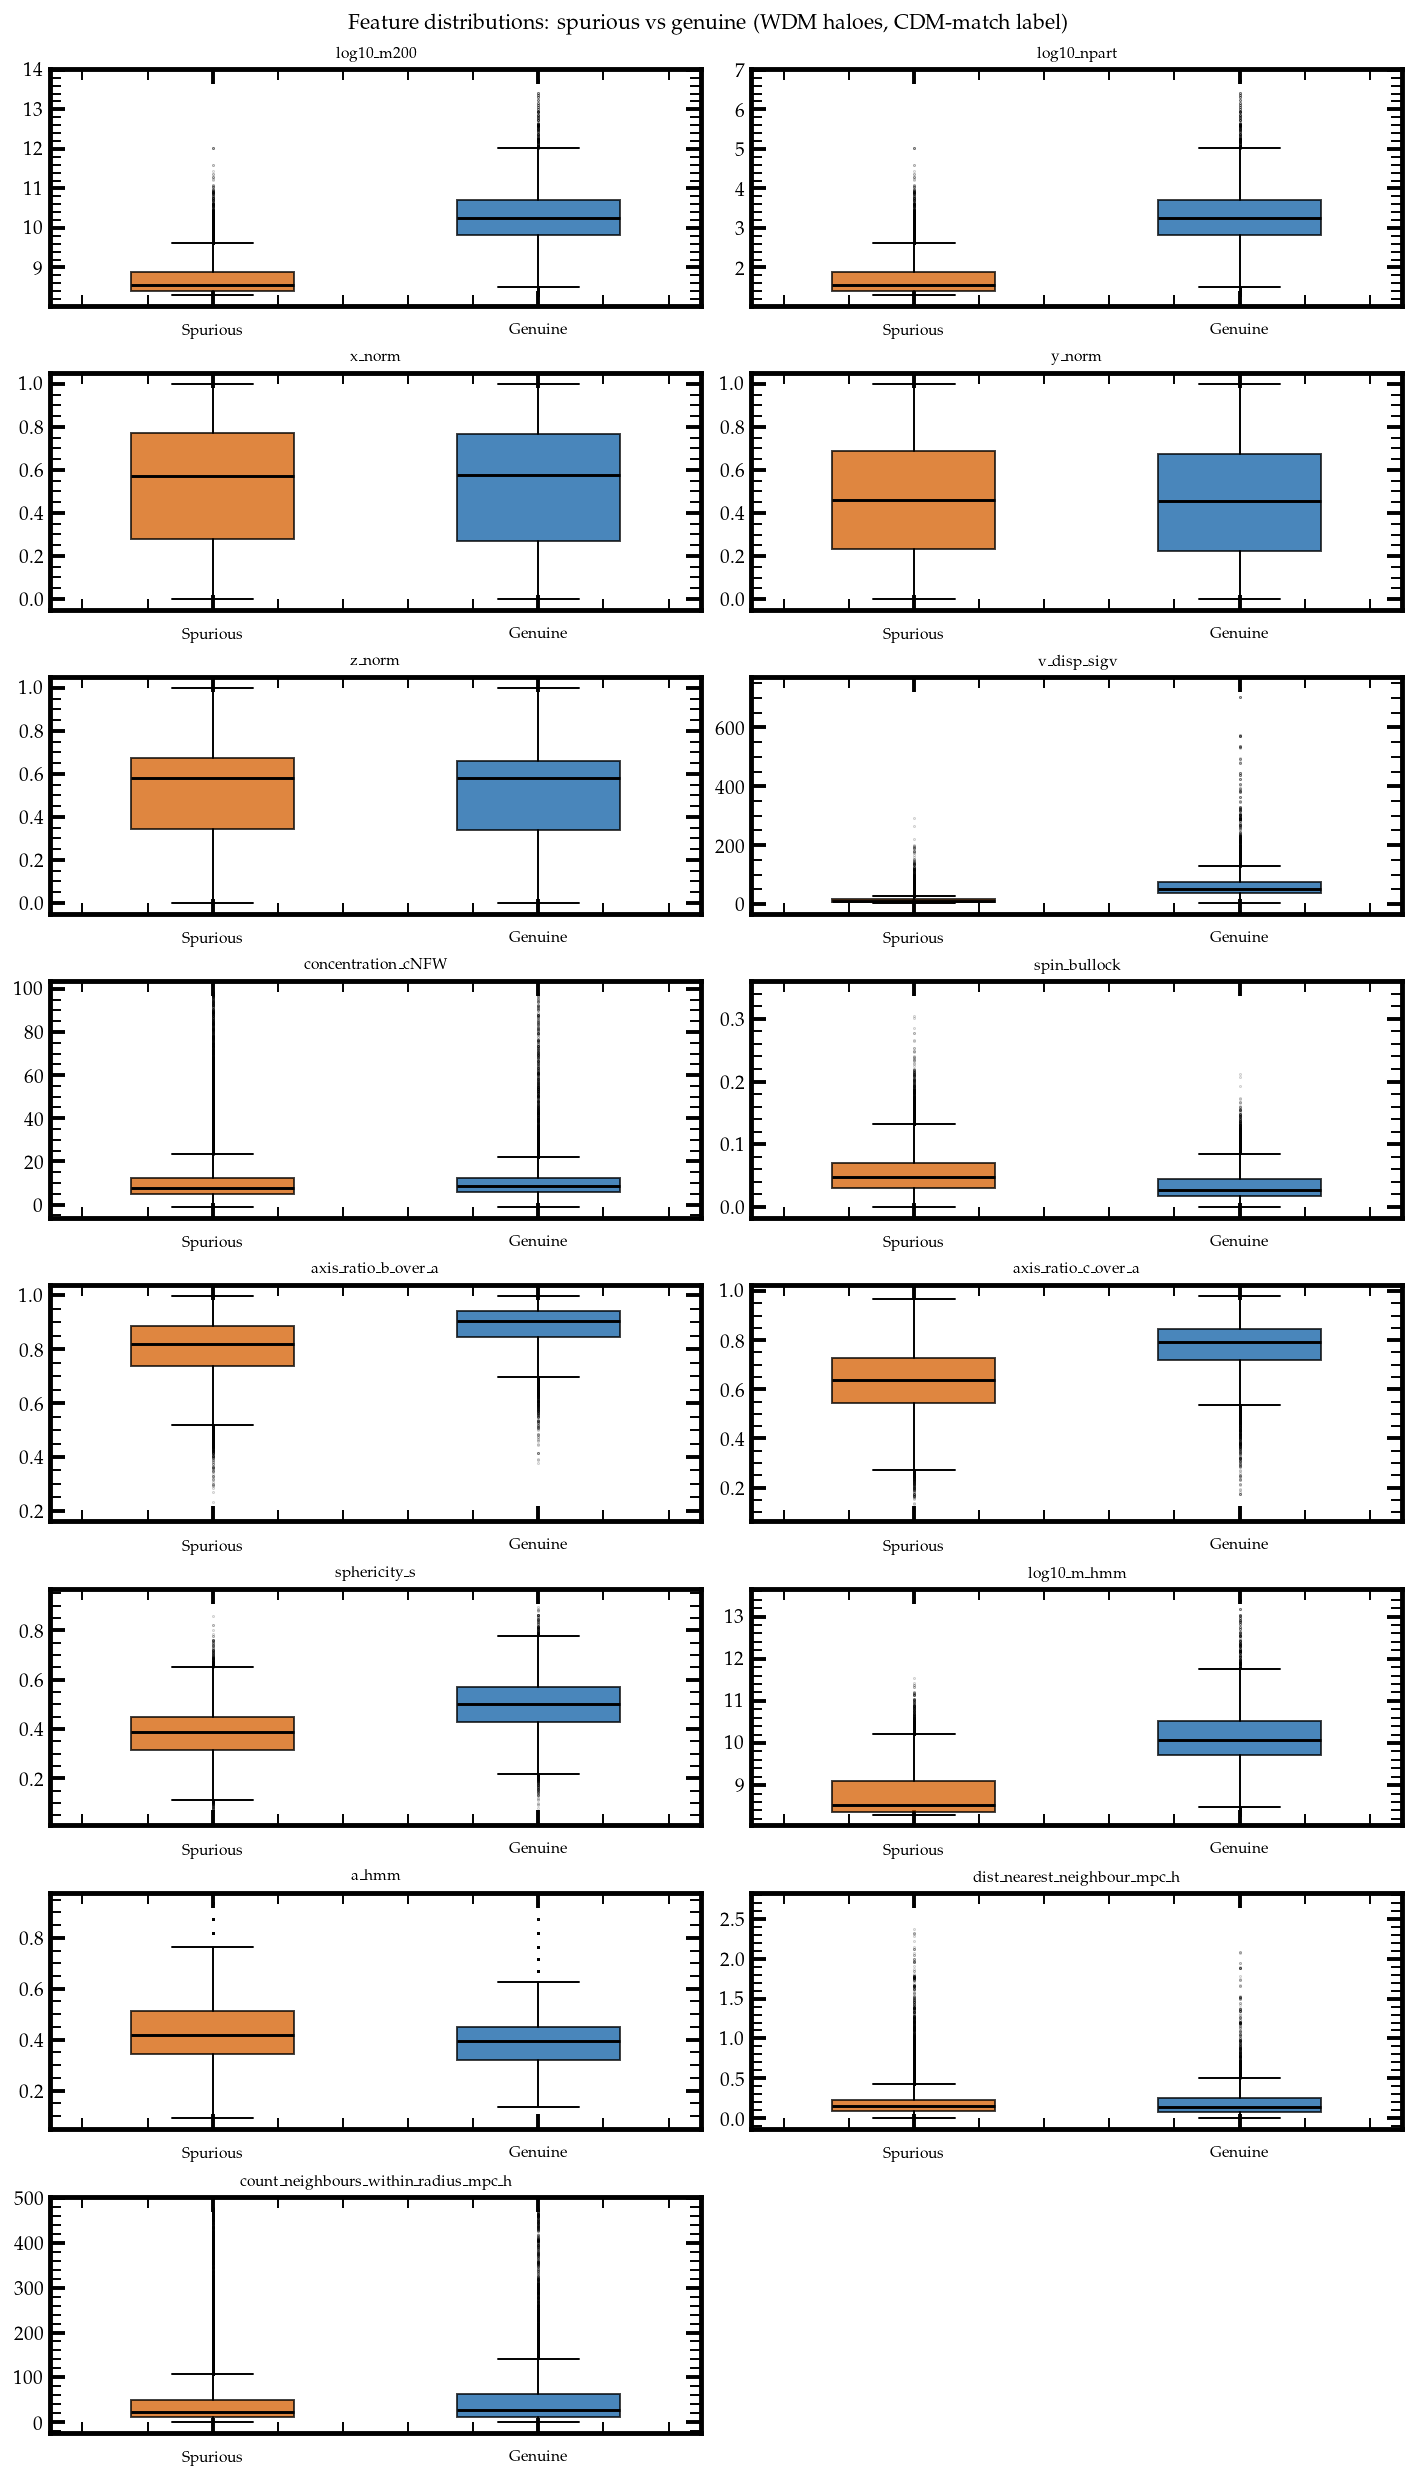

In [5]:
SPURIOUS_COLOR = "#D55E00"
GENUINE_COLOR  = "#0C5DA5"

spur = wdm.filter(pl.col("is_spurious_cdm_match") == True)
genu = wdm.filter(pl.col("is_spurious_cdm_match") == False)

n_cols = 2
n_rows = int(np.ceil(len(FEATURE_COLS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 2.2),
                         constrained_layout=True)
axes_flat = axes.ravel()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes_flat[i]
    s_vals = spur[feat].drop_nulls().to_numpy()
    g_vals = genu[feat].drop_nulls().to_numpy()
    bp = ax.boxplot(
        [s_vals, g_vals],
        vert=True,
        patch_artist=True,
        notch=False,
        widths=0.5,
        flierprops=dict(marker=".", markersize=1, alpha=0.2),
        medianprops=dict(color="black", linewidth=1.5),
    )
    for patch, color in zip(bp["boxes"], [SPURIOUS_COLOR, GENUINE_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    _ = ax.set_xticks([1, 2])
    _ = ax.set_xticklabels(["Spurious", "Genuine"], fontsize=8)
    _ = ax.set_title(feat, fontsize=8)

# Hide unused axes.
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

_ = fig.suptitle(
    "Feature distributions: spurious vs genuine (WDM haloes, CDM-match label)",
    fontsize=11,
)
fig.savefig(FIGURES_DIR / "04_feature_distributions_by_label.png", dpi=200, bbox_inches="tight")

## 3. Key features across simulation parameters

`log10_m200` and `v_disp_sigv` are the two most important features per SHAP analysis. 

Violin plots show how their WDM distributions vary across softening scheme and initial redshift.

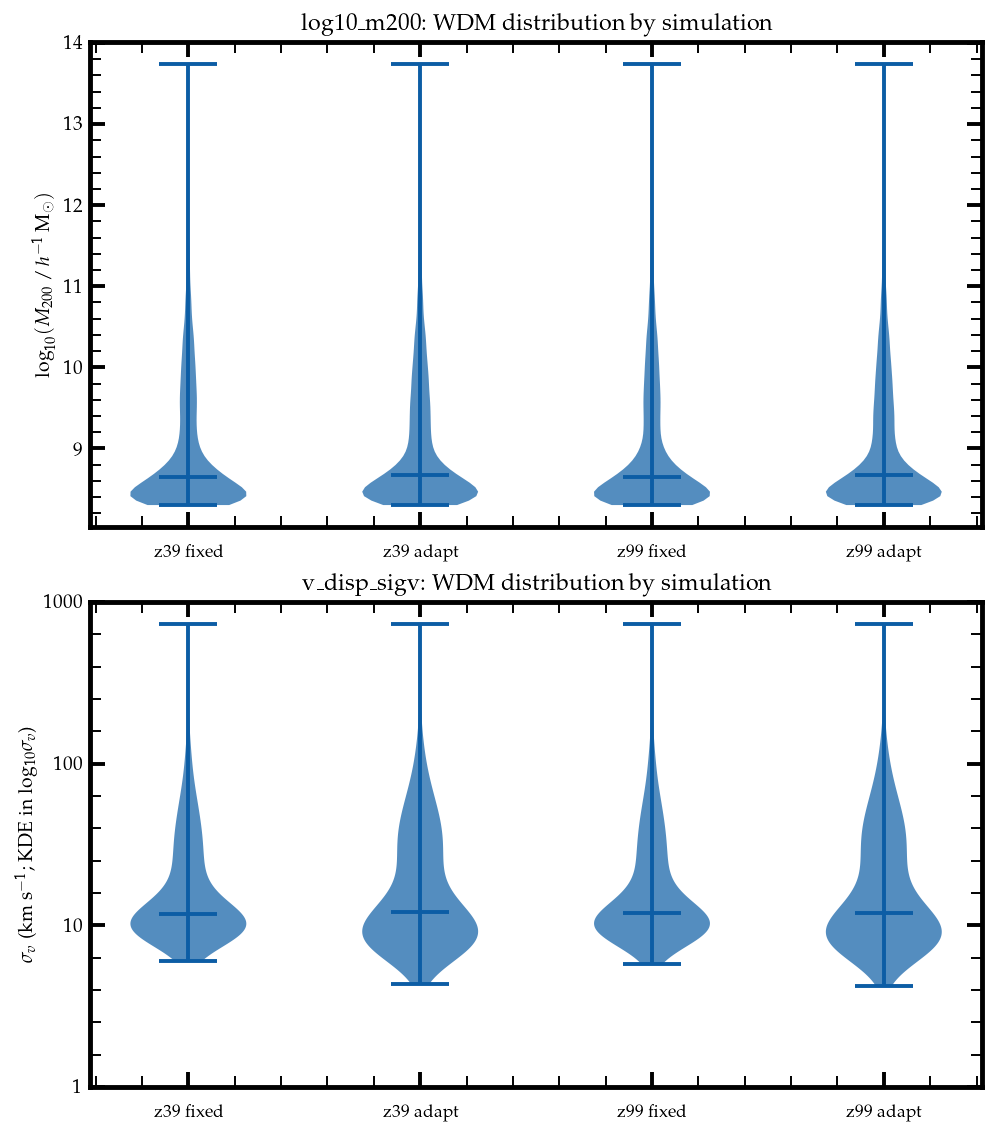

In [18]:
from matplotlib.ticker import FuncFormatter

SIM_GROUPS = {
    "z39 fixed":  "wdm_512_z39_fixed",
    "z39 adapt":  "wdm_512_z39_adapt",
    "z99 fixed":  "wdm_512_z99_fixed",
    "z99 adapt":  "wdm_512_z99_adapt",
}

FEAT_PAIRS = [
    ("log10_m200",  r"$\log_{10}(M_{200}\,/\,h^{-1}\,{\rm M}_\odot)$"),
    ("v_disp_sigv", r"$\sigma_v$ (km s$^{-1}$)"),
]

fig, axes = plt.subplots(len(FEAT_PAIRS), 1, figsize=(7, 8), constrained_layout=True)
for ax, (feat_name, ylabel) in zip(axes, FEAT_PAIRS):
    groups = []
    for sim_id in SIM_GROUPS.values():
        vals = wdm.filter(pl.col("simulation_id") == sim_id)[feat_name].drop_nulls().to_numpy()
        if feat_name == "v_disp_sigv":
            vals = vals[vals > 0]
            vals = np.log10(vals)
        groups.append(vals)

    if feat_name == "v_disp_sigv":
        vp = ax.violinplot(
            groups, positions=range(len(groups)), showmedians=True,
            bw_method=0.35, points=300,
        )
    else:
        vp = ax.violinplot(groups, positions=range(len(groups)), showmedians=True)

    for body in vp["bodies"]:
        body.set_alpha(0.7)
    _ = ax.set_xticks(range(len(SIM_GROUPS)))
    _ = ax.set_xticklabels(list(SIM_GROUPS.keys()), fontsize=9)
    _ = ax.set_title(f"{feat_name}: WDM distribution by simulation")

    if feat_name == "v_disp_sigv":
        y_min = min(np.min(g) for g in groups if len(g) > 0)
        y_max = max(np.max(g) for g in groups if len(g) > 0)
        tick_lo = int(np.floor(y_min))
        tick_hi = int(np.ceil(y_max))
        ticks = np.arange(tick_lo, tick_hi + 1, 1)
        _ = ax.set_yticks(ticks)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{10 ** y:.0f}"))
        _ = ax.set_ylabel(r"$\sigma_v$ (km s$^{-1}$; KDE in log$_{10}\sigma_v$)")
    else:
        _ = ax.set_ylabel(ylabel)

fig.savefig(FIGURES_DIR / "04_feature_mass_velocity_by_sim.png", dpi=200, bbox_inches="tight")

### Sphericity by initial redshift

Haloes initialised at $z_{\rm ini} = 99$ have ~6% lower protohalo sphericity overall (Fig. 7, Mostoghiu Paun et al. 2025). 

This shift invalidates the $z_{\rm ini} = 39$-derived empirical boundary when applied to $z_{\rm ini} = 99$ runs, which is the primary motivation for replacing the manual cut with a multi-feature classifier.

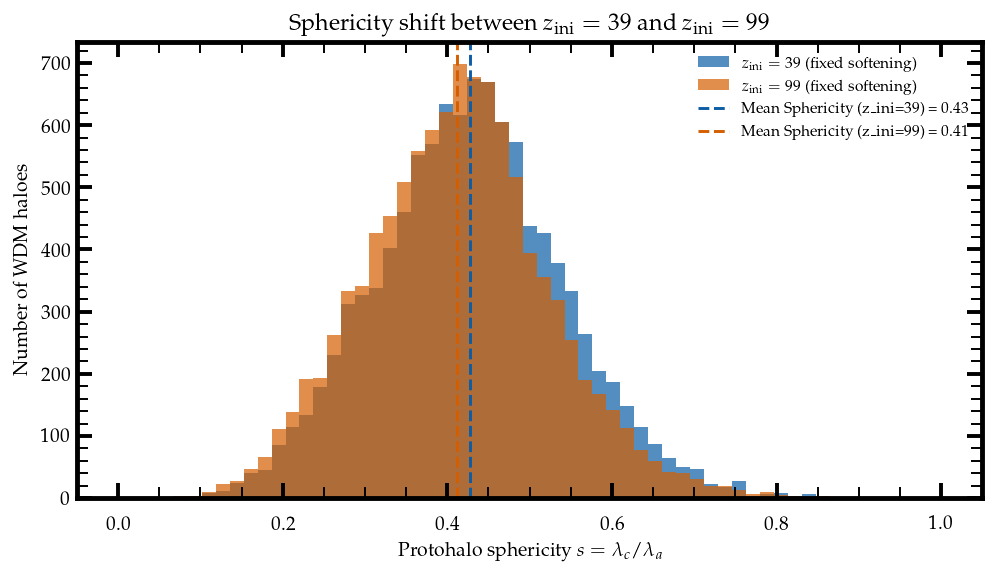

In [7]:
conn = get_connection(cfg.database_path, read_only=True)
sph_zini = conn.execute("""
    SELECT
        f.sphericity_s,
        f.z_ini
    FROM gold.features f
    WHERE f.cosmology = 'WDM'
      AND f.softening = 'fixed'
      AND f.sphericity_s IS NOT NULL
""").pl()
conn.close()

s_z39 = sph_zini.filter(pl.col("z_ini") == 39)["sphericity_s"].to_numpy()
s_z99 = sph_zini.filter(pl.col("z_ini") == 99)["sphericity_s"].to_numpy()

s_z39_mean = np.mean(s_z39)
s_z99_mean = np.mean(s_z99)

bins = np.linspace(0, 1, 60)
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
_ = ax.hist(s_z39, bins=bins, color="#0C5DA5", alpha=0.7,
            label=r"$z_{\rm ini} = 39$  (fixed softening)")
_ = ax.hist(s_z99, bins=bins, color="#D55E00", alpha=0.7,
            label=r"$z_{\rm ini} = 99$  (fixed softening)")
_ = ax.axvline(s_z39_mean, color="#0C5DA5", linestyle="--", linewidth=1.5,
            label=f"Mean Sphericity (z_ini=39) = {s_z39_mean:.2f}")
_ = ax.axvline(s_z99_mean, color="#D55E00", linestyle="--", linewidth=1.5,
            label=f"Mean Sphericity (z_ini=99) = {s_z99_mean:.2f}")
_ = ax.set_xlabel(r"Protohalo sphericity $s = \lambda_c / \lambda_a$")
_ = ax.set_ylabel("Number of WDM haloes")
_ = ax.set_title(r"Sphericity shift between $z_{\rm ini} = 39$ and $z_{\rm ini} = 99$")
_ = ax.legend()
fig.savefig(FIGURES_DIR / "04_sphericity_by_zini.png", dpi=200, bbox_inches="tight")

## 4. Spatial environment

Spurious haloes form as regularly-spaced “beads on a string” along filaments.
The periodic KD-tree neighbour features capture this clustering signal.

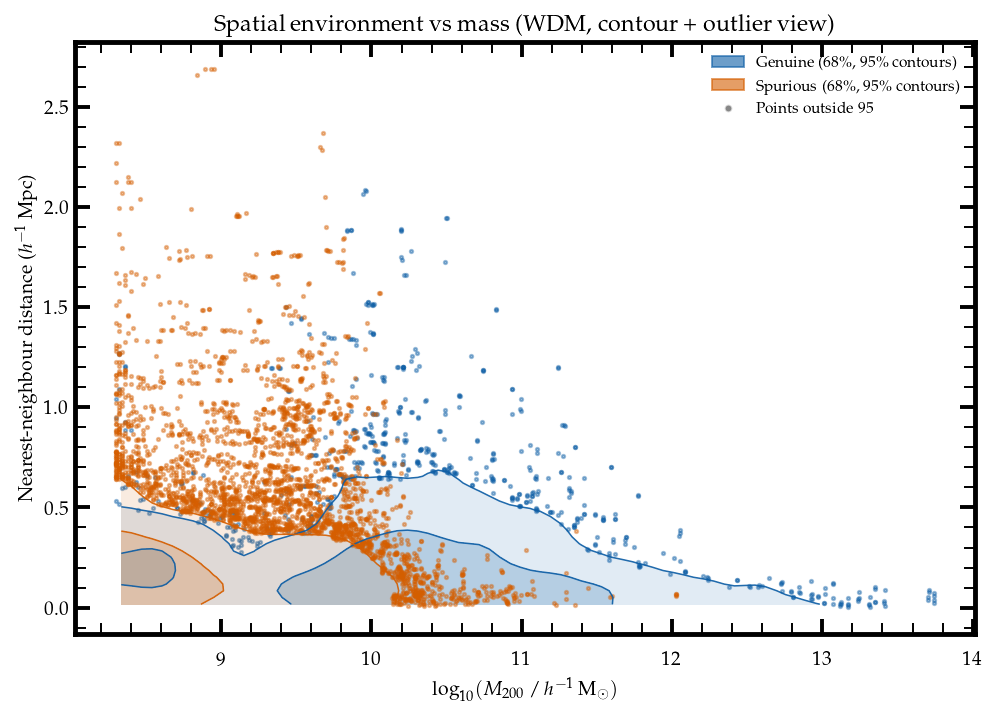

In [14]:
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D

x_gen = genu["log10_m200"].drop_nulls().to_numpy()
y_gen = genu["dist_nearest_neighbour_mpc_h"].drop_nulls().to_numpy()
x_spur = spur["log10_m200"].drop_nulls().to_numpy()
y_spur = spur["dist_nearest_neighbour_mpc_h"].drop_nulls().to_numpy()

x_all = np.concatenate([x_gen, x_spur])
y_all = np.concatenate([y_gen, y_spur])
x_lim = (float(x_all.min()), float(x_all.max()))
y_lim = (float(y_all.min()), float(y_all.max()))
BINS = 80


def density_contours(
    x: np.ndarray,
    y: np.ndarray,
    ax: plt.Axes,
    color: str,
    sigma: float = 1.5,
) -> np.ndarray:
    """Draw 68% and 95% density contours; return mask outside 95% contour."""
    h, xe, ye = np.histogram2d(x, y, bins=BINS, range=[x_lim, y_lim])
    h_smooth = gaussian_filter(h, sigma=sigma)

    total = h_smooth.sum()
    sorted_ = np.sort(h_smooth.ravel())[::-1]
    cumsum = np.cumsum(sorted_)
    thresh68 = sorted_[np.searchsorted(cumsum, 0.68 * total)]
    thresh95 = sorted_[np.searchsorted(cumsum, 0.95 * total)]

    xc = 0.5 * (xe[:-1] + xe[1:])
    yc = 0.5 * (ye[:-1] + ye[1:])

    _ = ax.contourf(
        xc, yc, h_smooth.T,
        levels=[thresh68, h_smooth.max()],
        colors=[color], alpha=0.30,
    )
    _ = ax.contourf(
        xc, yc, h_smooth.T,
        levels=[thresh95, thresh68],
        colors=[color], alpha=0.12,
    )
    _ = ax.contour(
        xc, yc, h_smooth.T,
        levels=[thresh95, thresh68],
        colors=color, linewidths=0.8, alpha=0.9,
    )

    xi = np.clip(np.digitize(x, xe) - 1, 0, BINS - 1)
    yi = np.clip(np.digitize(y, ye) - 1, 0, BINS - 1)
    return h_smooth[xi, yi] < thresh95


fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

out_gen = density_contours(x_gen, y_gen, ax, GENUINE_COLOR)
_ = ax.scatter(
    x_gen[out_gen], y_gen[out_gen],
    s=3, alpha=0.4, color=GENUINE_COLOR, rasterized=True,
)

out_spur = density_contours(x_spur, y_spur, ax, SPURIOUS_COLOR)
_ = ax.scatter(
    x_spur[out_spur], y_spur[out_spur],
    s=3, alpha=0.4, color=SPURIOUS_COLOR, rasterized=True,
)

gen_patch = mpatches.Patch(
    color=GENUINE_COLOR, alpha=0.6,
    label=r"Genuine (68\%, 95\% contours)",
)
spur_patch = mpatches.Patch(
    color=SPURIOUS_COLOR, alpha=0.6,
    label=r"Spurious (68\%, 95\% contours)",
)
outlier_marker = Line2D(
    [0], [0], marker="o", color="w", markerfacecolor="#555555",
    markersize=4, alpha=0.7, label="Points outside 95% contours",
)
_ = ax.legend(handles=[gen_patch, spur_patch, outlier_marker], fontsize=8)

_ = ax.set_xlabel(r"$\log_{10}(M_{200}\,/\,h^{-1}\,{\rm M}_\odot)$")
_ = ax.set_ylabel(r"Nearest-neighbour distance ($h^{-1}\,{\rm Mpc}$)")
_ = ax.set_title("Spatial environment vs mass (WDM, contour + outlier view)")
fig.savefig(FIGURES_DIR / "04_spatial_environment_contours.png", dpi=200, bbox_inches="tight")

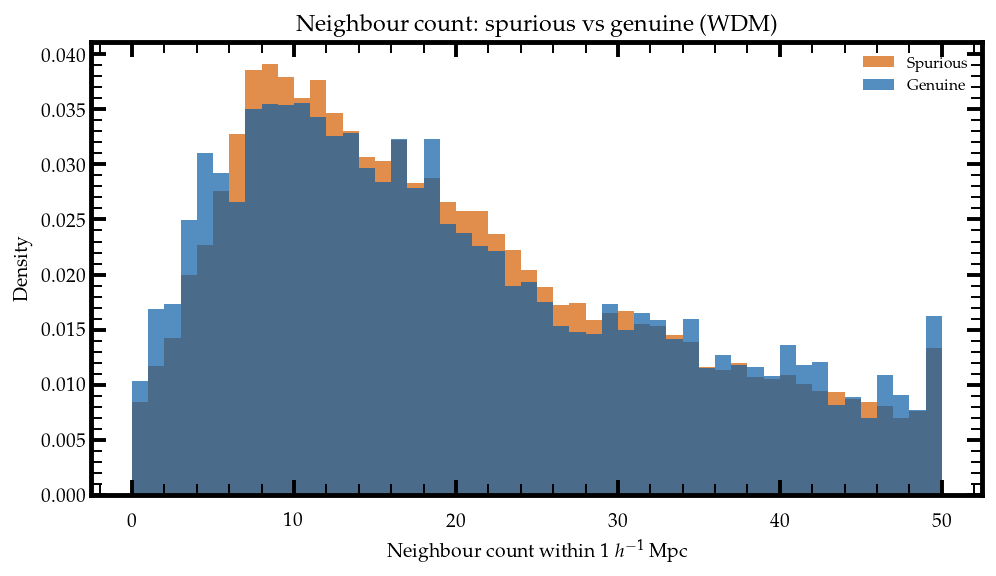

In [9]:
bins = np.arange(0, 51, 1)
s_nn = spur["count_neighbours_within_radius_mpc_h"].drop_nulls().to_numpy()
g_nn = genu["count_neighbours_within_radius_mpc_h"].drop_nulls().to_numpy()

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
_ = ax.hist(s_nn, bins=bins, color=SPURIOUS_COLOR, alpha=0.7, density=True,
            label="Spurious")
_ = ax.hist(g_nn, bins=bins, color=GENUINE_COLOR, alpha=0.7, density=True,
            label="Genuine")
_ = ax.set_xlabel(r"Neighbour count within 1 $h^{-1}\,{\rm Mpc}$")
_ = ax.set_ylabel("Density")
_ = ax.set_title("Neighbour count: spurious vs genuine (WDM)")
_ = ax.legend()